# Wave 7 (Knapsack) & Wave 2 (Energy) — Objective Loss + val_frac=0.5

**Changes from previous waves:**
- `loss_type: objective` — directly optimizes $c^\top \bar{z}$ instead of regret $|f(\theta^*, \bar{z}) - f(\theta^*, z^*)|$. No extra solver call.
- `val_frac=0.5` — equal-size train/val splits. Test set unchanged.

**Top-5 models** selected by best validation regret from all prior waves.

| Problem   | #Exps | Configs | Submit Script |
|-----------|-------|---------|---------------|
| Knapsack  | 5     | `perturb_kn_w7_*.yaml` | `shells/slurm/submit_knapsack_wave7.sh` |
| Energy    | 5     | `perturb_en_w2_*.yaml` | `shells/slurm/submit_energy_wave2.sh` |

In [1]:
import os, sys, glob, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.chdir(os.path.expanduser(
    "/cluster/tufts/hugheslab/kheuto01/code/PredictiveCO-Benchmark"))

from rethink_exp.exp_helpers import (
    read_result, read_traces, read_full_traces,
    get_best_val_regret, collect_results, scan_slurm_errors,
)

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120})
print("Helpers loaded.")

Helpers loaded.


## Experiment Registries

In [2]:
# ── KN-W7: Knapsack objective-loss experiments ─────────────────────
KN_W7 = {
    "sd1_kn_w7_tanh_s05_n50_lr1e2": {
        "act": "tanh", "sigma": 0.5, "n_samples": 50, "lr": 0.01,
        "source": "sd1_kn_w6_tanh_s05_lr1e2",
    },
    "sd1_kn_w7_none_s05_n25_lr5e3": {
        "act": "none", "sigma": 0.5, "n_samples": 25, "lr": 0.005,
        "source": "sd1_s05_lr5e3",
    },
    "sd1_kn_w7_tanh_s10_n50_lr1e2": {
        "act": "tanh", "sigma": 1.0, "n_samples": 50, "lr": 0.01,
        "source": "sd1_kn_w6_tanh_s10_lr1e2",
    },
    "sd1_kn_w7_none_s05_n25_lr1e2": {
        "act": "none", "sigma": 0.5, "n_samples": 25, "lr": 0.01,
        "source": "sd1_s05_lr1e2",
    },
    "sd1_kn_w7_none_s10_n5_lr5e3": {
        "act": "none", "sigma": 1.0, "n_samples": 5, "lr": 0.005,
        "source": "sd1_kn_n5_s10_plw0_lr5e3",
    },
}

# ── EN-W2: Energy objective-loss experiments ──────────────────────
EN_W2 = {
    "sd1_en_w2_sig_s05_lr5e2": {
        "act": "sigmoid", "sigma": 0.5, "n_samples": 1, "lr": 0.05,
        "source": "sd1_en_w1_sig_s05_lr5e2",
    },
    "sd1_en_w2_sig_s05_lr1e2": {
        "act": "sigmoid", "sigma": 0.5, "n_samples": 1, "lr": 0.01,
        "source": "sd1_en_w1_sig_s05_lr1e2",
    },
    "sd1_en_w2_sig_s05_ann_lr1e2": {
        "act": "sigmoid", "sigma": 0.5, "n_samples": 1, "lr": 0.01,
        "anneal": True,
        "source": "sd1_en_w1_sig_s05_ann_lr1e2",
    },
    "sd1_en_w2_none_s05_n25_lr1e2": {
        "act": "none", "sigma": 0.5, "n_samples": 25, "lr": 0.01,
        "source": "sd1_s05_lr1e2",
    },
    "sd1_en_w2_sig_s01_lr1e2": {
        "act": "sigmoid", "sigma": 0.1, "n_samples": 1, "lr": 0.01,
        "source": "sd1_en_w1_sig_s01_lr1e2",
    },
}

print(f"KN-W7: {len(KN_W7)} experiments")
print(f"EN-W2: {len(EN_W2)} experiments")

KN-W7: 5 experiments
EN-W2: 5 experiments


## Launch / Status

In [3]:
# Dry-run both waves
!bash shells/slurm/submit_knapsack_wave7.sh --dry-run 2>&1
!echo "\n"
!bash shells/slurm/submit_energy_wave2.sh --dry-run 2>&1

Wave 7 — Knapsack: objective loss, val_frac=0.5
5 experiments (top-5 by val regret)
Primary: preempt
Backup: hugheslab,gpu
n_epochs=500 | patience=150 | val_frac=0.5
*** DRY RUN ***
Skip completed: ON

[DRY RUN] pco_knapsack_sd1_kn_w7_tanh_s05_n50_lr1e2
  CMD: python rethink_exp/main_results.py --problem=knapsack --opt_model perturb --method_path openpto/config/models/perturb_kn_w7_tanh_s05_n50.yaml --prefix sd1_kn_w7_tanh_s05_n50_lr1e2 --solver gurobi --n_epochs 500 --patience 150 --lr 0.01 --val_frac 0.5 --data_dir ./openpto/data/knapsack --gpu 0

[DRY RUN] pco_knapsack_sd1_kn_w7_none_s05_n25_lr5e3
  CMD: python rethink_exp/main_results.py --problem=knapsack --opt_model perturb --method_path openpto/config/models/perturb_kn_w7_none_s05_n25.yaml --prefix sd1_kn_w7_none_s05_n25_lr5e3 --solver gurobi --n_epochs 500 --patience 150 --lr 0.005 --val_frac 0.5 --data_dir ./openpto/data/knapsack --gpu 0

[DRY RUN] pco_knapsack_sd1_kn_w7_tanh_s10_n50_lr1e2
  CMD: python rethink_exp/main_result

In [4]:
# Uncomment to launch
#!bash shells/slurm/submit_knapsack_wave7.sh
#!bash shells/slurm/submit_energy_wave2.sh

In [5]:
# Check SLURM queue
!squeue --me | grep -E 'pco_knapsack_sd1_kn_w7|pco_energy_sd1_en_w2' | wc -l && \
 echo "active W7/W2 jobs" && \
 squeue --me | grep -E 'pco_knapsack_sd1_kn_w7|pco_energy_sd1_en_w2'

0
active W7/W2 jobs


## Knapsack W7 — Collect Results

In [6]:
kn_w7_df = collect_results(KN_W7, "knapsack-gen")
kn_w7_done = kn_w7_df[kn_w7_df["status"] == "done"]
print(f"Knapsack W7: {len(kn_w7_done)}/{len(kn_w7_df)} completed\n")

if len(kn_w7_done) > 0:
    # Compare against source (regret-loss) runs
    print(f"{'prefix':<40s} {'regret':>8s}  {'obj':>8s}  {'source (regret-loss)'}")
    print("-" * 90)
    for _, r in kn_w7_done.sort_values("regret").iterrows():
        src = read_result("knapsack-gen", r["source"])
        src_reg = f"{src['regret']:.3f}" if src else "n/a"
        print(f"  {r['prefix']:<38s} {r['regret']:>8.3f}  {r['objective']:>8.3f}  "
              f"← {r['source']} ({src_reg})")
else:
    pending = kn_w7_df[kn_w7_df["status"] == "pending"]
    print(f"No results yet. {len(pending)} experiments pending.")

Knapsack W7: 0/5 completed

No results yet. 5 experiments pending.


## Knapsack W7 — Training Curves

KN W7: 5/5 traces, 5 baselines


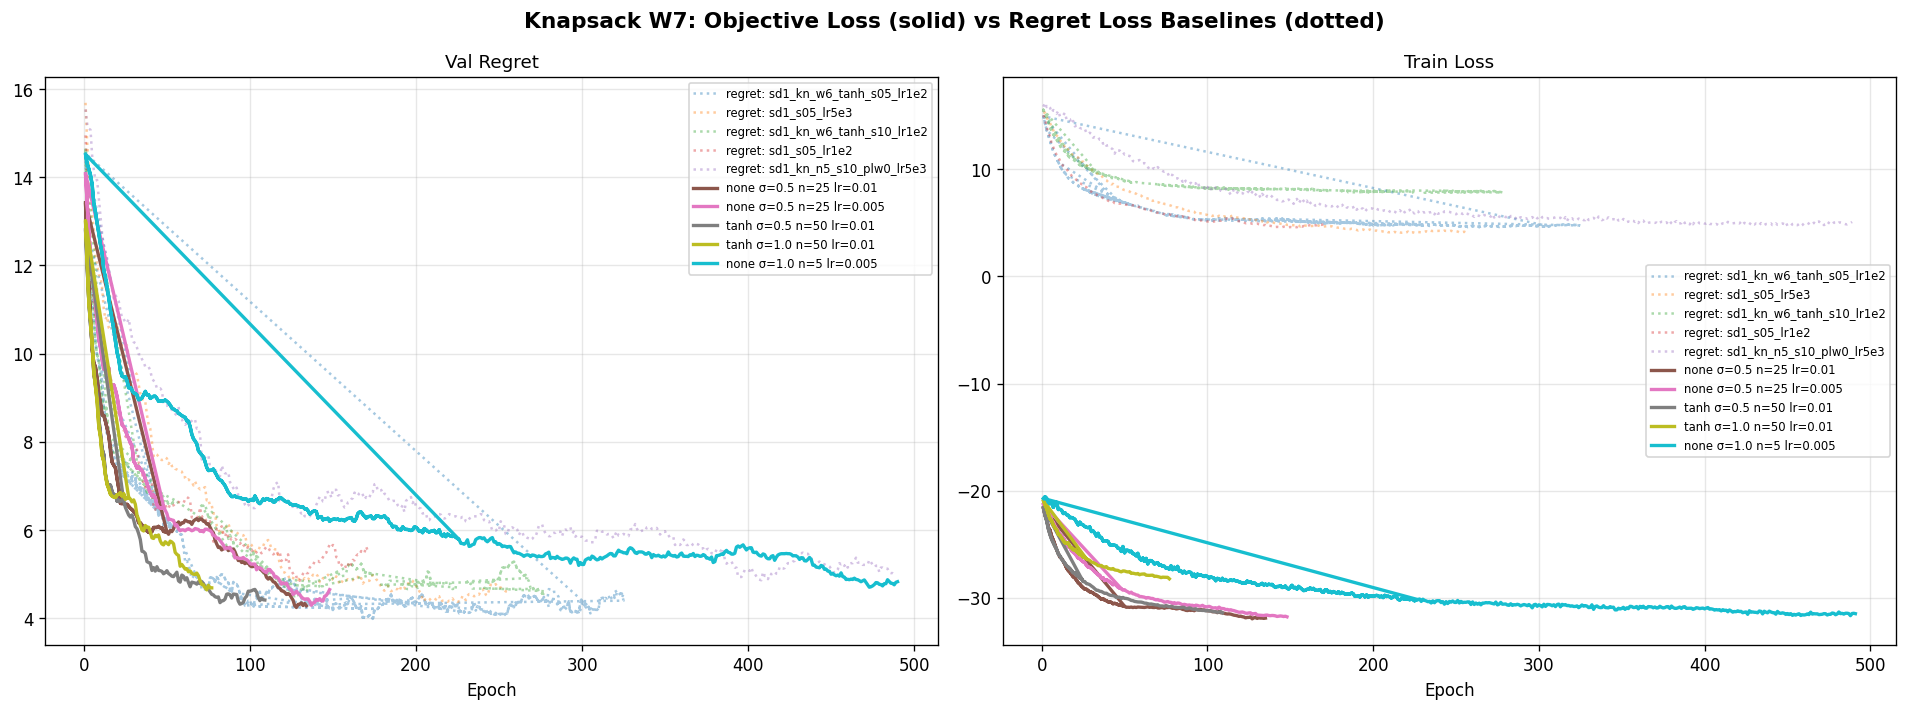


Knapsack W7 ranking by best val regret:
  1. none σ=0.5 n=25 lr=0.01                   val_regret=4.2450
  2. none σ=0.5 n=25 lr=0.005                  val_regret=4.2950
  3. tanh σ=0.5 n=50 lr=0.01                   val_regret=4.3200
  4. tanh σ=1.0 n=50 lr=0.01                   val_regret=4.6450
  5. none σ=1.0 n=5 lr=0.005                   val_regret=4.7050
  baseline: regret: sd1_kn_w6_tanh_s05_lr1e2       val_regret=3.9875
  baseline: regret: sd1_s05_lr5e3                  val_regret=4.3750
  baseline: regret: sd1_kn_w6_tanh_s10_lr1e2       val_regret=4.5000
  baseline: regret: sd1_s05_lr1e2                  val_regret=4.8500
  baseline: regret: sd1_kn_n5_s10_plw0_lr5e3       val_regret=4.8625


In [7]:
# ── Load traces ────────────────────────────────────────────────────
kn_w7_traces = []
for prefix, hp in KN_W7.items():
    tdf, vdf, ddf = read_full_traces("knapsack-gen", prefix)
    if tdf is not None:
        best_val = get_best_val_regret(vdf)
        label = f"{hp['act']} σ={hp['sigma']} n={hp['n_samples']} lr={hp['lr']}"
        kn_w7_traces.append({
            "label": label, "train": tdf, "val": vdf, "diag": ddf,
            "best_val_regret": best_val, "prefix": prefix,
        })

# Baselines: the source regret-loss runs
kn_w7_baselines = []
for prefix, hp in KN_W7.items():
    src = hp["source"]
    if any(b["prefix"] == src for b in kn_w7_baselines):
        continue  # already added
    tdf, vdf, ddf = read_full_traces("knapsack-gen", src)
    if tdf is not None:
        kn_w7_baselines.append({
            "label": f"regret: {src}", "train": tdf, "val": vdf, "diag": ddf,
            "best_val_regret": get_best_val_regret(vdf), "prefix": src,
        })

print(f"KN W7: {len(kn_w7_traces)}/{len(KN_W7)} traces, {len(kn_w7_baselines)} baselines")

if len(kn_w7_traces) > 0:
    kn_w7_traces.sort(key=lambda t: t["best_val_regret"])

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    for title, source, col, ax in [
        ("Val Regret", "val", "regret", axes[0]),
        ("Train Loss", "train", "loss", axes[1]),
    ]:
        for i, bl in enumerate(kn_w7_baselines):
            df_bl = bl[source]
            if df_bl is not None and col in df_bl.columns:
                ax.plot(df_bl["epoch"], df_bl[col], color=f"C{i}", alpha=0.4,
                        linestyle=":", linewidth=1.5, label=bl["label"])
        for i, tr in enumerate(kn_w7_traces):
            df_tr = tr[source]
            if df_tr is not None and col in df_tr.columns:
                ax.plot(df_tr["epoch"], df_tr[col], color=f"C{len(kn_w7_baselines)+i}",
                        linewidth=2.0, label=tr["label"])
        ax.set_xlabel("Epoch"); ax.set_title(title, fontsize=11)
        ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    fig.suptitle("Knapsack W7: Objective Loss (solid) vs Regret Loss Baselines (dotted)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout(); plt.show()

    print("\nKnapsack W7 ranking by best val regret:")
    for i, tr in enumerate(kn_w7_traces):
        print(f"  {i+1}. {tr['label']:40s}  val_regret={tr['best_val_regret']:.4f}")
    for bl in kn_w7_baselines:
        print(f"  baseline: {bl['label']:37s}  val_regret={bl['best_val_regret']:.4f}")
else:
    print("No KN W7 traces yet — re-run after jobs complete.")

## Knapsack W7 — SLURM Error Scanner

In [8]:
scan_slurm_errors("logs/slurm/pco_knapsack_sd1_kn_w7_*.err")

Found 15 error files

⚠ pco_knapsack_sd1_kn_w7_none_s05_n25_lr1e2_32655958.err:
   slurmstepd: error: *** JOB 32655958 ON s1cmp011 CANCELLED AT 2026-03-05T18:58:16 ***

⚠ pco_knapsack_sd1_kn_w7_none_s05_n25_lr1e2_32678966.err:
   slurmstepd: error: *** JOB 32678966 ON d1cmp045 CANCELLED AT 2026-03-05T19:36:45 DUE TO PREEMPTION ***

⚠ pco_knapsack_sd1_kn_w7_none_s05_n25_lr5e3_32655953.err:
   slurmstepd: error: *** JOB 32655953 ON s1cmp011 CANCELLED AT 2026-03-05T18:58:16 ***

⚠ pco_knapsack_sd1_kn_w7_none_s05_n25_lr5e3_32678962.err:
   slurmstepd: error: *** JOB 32678962 ON d1cmp045 CANCELLED AT 2026-03-05T19:36:42 DUE TO PREEMPTION ***

⚠ pco_knapsack_sd1_kn_w7_none_s10_n5_lr5e3_32655960.err:
   slurmstepd: error: *** JOB 32655960 ON s1cmp011 CANCELLED AT 2026-03-05T18:58:16 ***

⚠ pco_knapsack_sd1_kn_w7_none_s10_n5_lr5e3_32678968.err:
   slurmstepd: error: *** JOB 32678968 ON d1cmp046 CANCELLED AT 2026-03-05T19:36:47 DUE TO PREEMPTION ***

⚠ pco_knapsack_sd1_kn_w7_tanh_s05_n50_lr1e2_

10

---
## Energy W2 — Collect Results

In [9]:
en_w2_df = collect_results(EN_W2, "energy-energy")
en_w2_done = en_w2_df[en_w2_df["status"] == "done"]
print(f"Energy W2: {len(en_w2_done)}/{len(en_w2_df)} completed\n")

if len(en_w2_done) > 0:
    print(f"{'prefix':<40s} {'regret':>10s}  {'obj':>12s}  {'source (regret-loss)'}")
    print("-" * 100)
    for _, r in en_w2_done.sort_values("regret").iterrows():
        src = read_result("energy-energy", r["source"])
        src_reg = f"{src['regret']:.1f}" if src else "n/a"
        print(f"  {r['prefix']:<38s} {r['regret']:>10.1f}  {r['objective']:>12.1f}  "
              f"← {r['source']} ({src_reg})")
else:
    pending = en_w2_df[en_w2_df["status"] == "pending"]
    print(f"No results yet. {len(pending)} experiments pending.")

Energy W2: 0/5 completed

No results yet. 5 experiments pending.


## Energy W2 — Training Curves

EN W2: 5/5 traces, 5 baselines


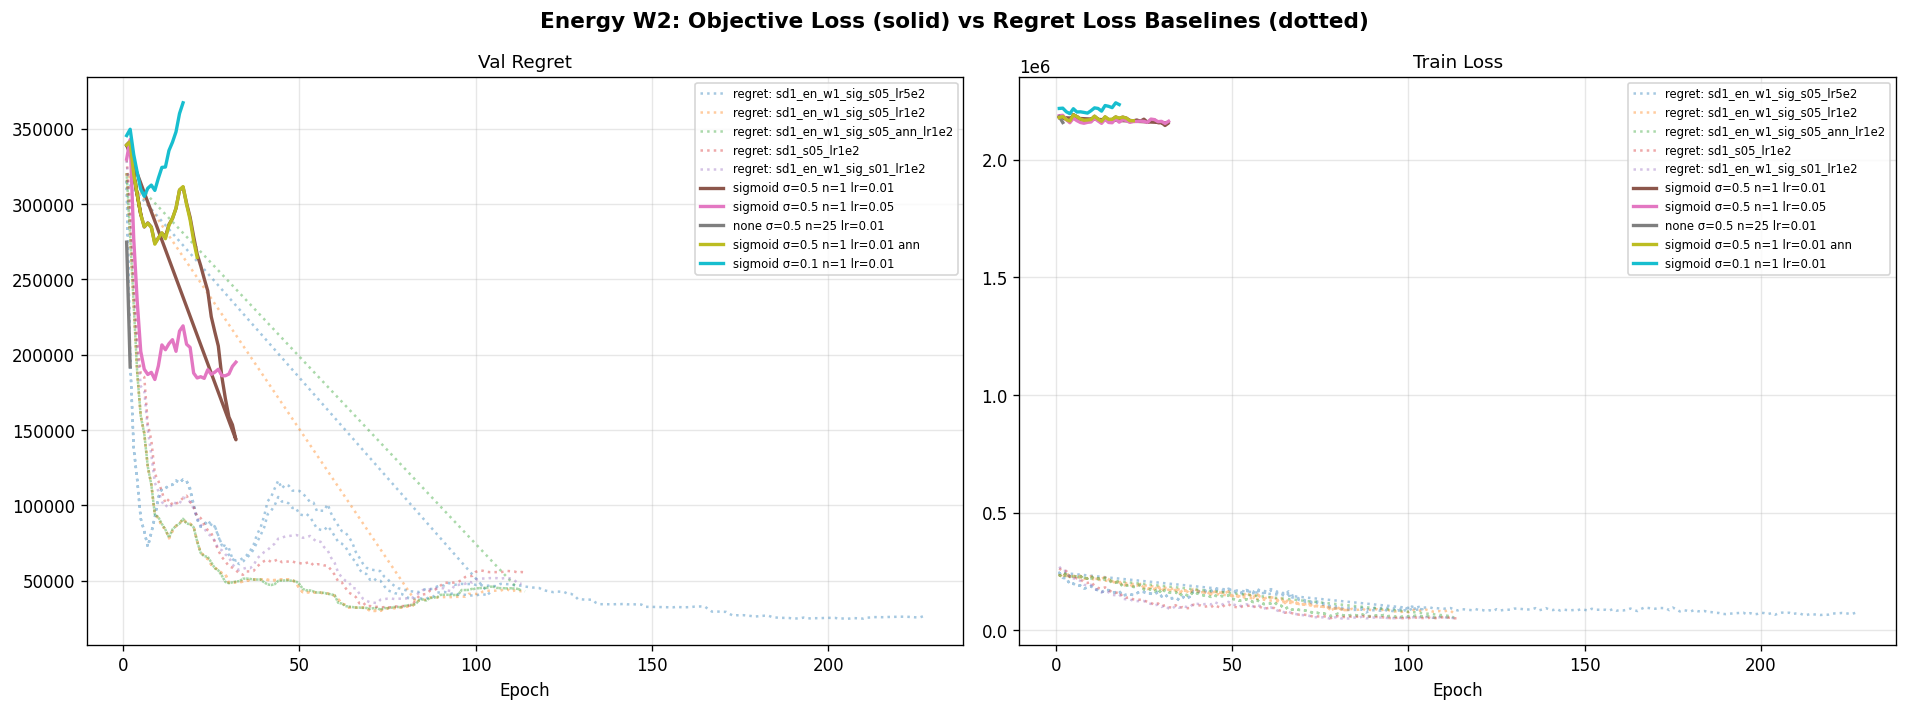


Energy W2 ranking by best val regret:
  1. sigmoid σ=0.5 n=1 lr=0.01                 val_regret=143568.1
  2. sigmoid σ=0.5 n=1 lr=0.05                 val_regret=183564.9
  3. none σ=0.5 n=25 lr=0.01                   val_regret=191922.1
  4. sigmoid σ=0.5 n=1 lr=0.01 ann             val_regret=264631.8
  5. sigmoid σ=0.1 n=1 lr=0.01                 val_regret=305117.7
  baseline: regret: sd1_en_w1_sig_s05_lr5e2        val_regret=24716.4
  baseline: regret: sd1_en_w1_sig_s05_lr1e2        val_regret=29921.2
  baseline: regret: sd1_en_w1_sig_s05_ann_lr1e2    val_regret=30713.4
  baseline: regret: sd1_s05_lr1e2                  val_regret=32350.0
  baseline: regret: sd1_en_w1_sig_s01_lr1e2        val_regret=35165.8


In [10]:
# ── Load traces ────────────────────────────────────────────────────
en_w2_traces = []
for prefix, hp in EN_W2.items():
    tdf, vdf, ddf = read_full_traces("energy-energy", prefix)
    if tdf is not None:
        best_val = get_best_val_regret(vdf)
        ann_tag = " ann" if hp.get("anneal") else ""
        label = f"{hp['act']} σ={hp['sigma']} n={hp['n_samples']} lr={hp['lr']}{ann_tag}"
        en_w2_traces.append({
            "label": label, "train": tdf, "val": vdf, "diag": ddf,
            "best_val_regret": best_val, "prefix": prefix,
        })

# Baselines: the source regret-loss runs
en_w2_baselines = []
for prefix, hp in EN_W2.items():
    src = hp["source"]
    if any(b["prefix"] == src for b in en_w2_baselines):
        continue
    tdf, vdf, ddf = read_full_traces("energy-energy", src)
    if tdf is not None:
        en_w2_baselines.append({
            "label": f"regret: {src}", "train": tdf, "val": vdf, "diag": ddf,
            "best_val_regret": get_best_val_regret(vdf), "prefix": src,
        })

print(f"EN W2: {len(en_w2_traces)}/{len(EN_W2)} traces, {len(en_w2_baselines)} baselines")

if len(en_w2_traces) > 0:
    en_w2_traces.sort(key=lambda t: t["best_val_regret"])

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    for title, source, col, ax in [
        ("Val Regret", "val", "regret", axes[0]),
        ("Train Loss", "train", "loss", axes[1]),
    ]:
        for i, bl in enumerate(en_w2_baselines):
            df_bl = bl[source]
            if df_bl is not None and col in df_bl.columns:
                ax.plot(df_bl["epoch"], df_bl[col], color=f"C{i}", alpha=0.4,
                        linestyle=":", linewidth=1.5, label=bl["label"])
        for i, tr in enumerate(en_w2_traces):
            df_tr = tr[source]
            if df_tr is not None and col in df_tr.columns:
                ax.plot(df_tr["epoch"], df_tr[col], color=f"C{len(en_w2_baselines)+i}",
                        linewidth=2.0, label=tr["label"])
        ax.set_xlabel("Epoch"); ax.set_title(title, fontsize=11)
        ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    fig.suptitle("Energy W2: Objective Loss (solid) vs Regret Loss Baselines (dotted)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout(); plt.show()

    print("\nEnergy W2 ranking by best val regret:")
    for i, tr in enumerate(en_w2_traces):
        print(f"  {i+1}. {tr['label']:40s}  val_regret={tr['best_val_regret']:.1f}")
    for bl in en_w2_baselines:
        print(f"  baseline: {bl['label']:37s}  val_regret={bl['best_val_regret']:.1f}")
else:
    print("No EN W2 traces yet — re-run after jobs complete.")

## Energy W2 — SLURM Error Scanner

In [11]:
scan_slurm_errors("logs/slurm/pco_energy_sd1_en_w2_*.err")

Found 11 error files

⚠ pco_energy_sd1_en_w2_none_s05_n25_lr1e2_32656012.err:
   slurmstepd: error: *** JOB 32656012 ON p1cmp107 CANCELLED AT 2026-03-05T18:58:16 ***

⚠ pco_energy_sd1_en_w2_sig_s01_lr1e2_32656014.err:
   slurmstepd: error: *** JOB 32656014 ON p1cmp107 CANCELLED AT 2026-03-05T18:58:16 ***

⚠ pco_energy_sd1_en_w2_sig_s05_ann_lr1e2_32656010.err:
   slurmstepd: error: *** JOB 32656010 ON d1cmp045 CANCELLED AT 2026-03-05T18:58:16 ***

⚠ pco_energy_sd1_en_w2_sig_s05_lr1e2_32656007.err:
   slurmstepd: error: *** JOB 32656007 ON d1cmp045 CANCELLED AT 2026-03-05T18:58:16 ***

⚠ pco_energy_sd1_en_w2_sig_s05_lr1e2_32679051.err:
   slurmstepd: error: *** JOB 32679051 ON d1cmp042 CANCELLED AT 2026-03-05T21:13:47 DUE TO PREEMPTION ***

⚠ pco_energy_sd1_en_w2_sig_s05_lr5e2_32656005.err:
   slurmstepd: error: *** JOB 32656005 ON d1cmp046 CANCELLED AT 2026-03-05T18:58:16 ***



6

---
## Cross-Wave Comparison

Compare objective-loss (W7/W2) vs regret-loss (source runs) head-to-head.

In [12]:
# ── Head-to-head: objective vs regret for each config ─────────────
for prob_name, registry, data_name in [
    ("Knapsack", KN_W7, "knapsack-gen"),
    ("Energy",   EN_W2, "energy-energy"),
]:
    print(f"\n{'='*70}")
    print(f"  {prob_name}: Objective Loss vs Regret Loss")
    print(f"{'='*70}")
    print(f"  {'Config':<35s} {'Obj-Loss':>10s} {'Regret-Loss':>12s} {'Δ':>8s}")
    print(f"  {'-'*35} {'-'*10} {'-'*12} {'-'*8}")

    for prefix, hp in registry.items():
        new = read_result(data_name, prefix)
        old = read_result(data_name, hp["source"])
        new_r = f"{new['regret']:.4f}" if new else "pending"
        old_r = f"{old['regret']:.4f}" if old else "n/a"
        if new and old:
            delta = new["regret"] - old["regret"]
            delta_s = f"{delta:+.4f}"
        else:
            delta_s = ""
        short = prefix.replace("sd1_kn_w7_", "").replace("sd1_en_w2_", "")
        print(f"  {short:<35s} {new_r:>10s} {old_r:>12s} {delta_s:>8s}")


  Knapsack: Objective Loss vs Regret Loss
  Config                                Obj-Loss  Regret-Loss        Δ
  ----------------------------------- ---------- ------------ --------
  tanh_s05_n50_lr1e2                     pending       4.1550         
  none_s05_n25_lr5e3                     pending       3.5800         
  tanh_s10_n50_lr1e2                     pending       4.3050         
  none_s05_n25_lr1e2                     pending       4.2300         
  none_s10_n5_lr5e3                      pending       4.1400         

  Energy: Objective Loss vs Regret Loss
  Config                                Obj-Loss  Regret-Loss        Δ
  ----------------------------------- ---------- ------------ --------
  sig_s05_lr5e2                          pending          n/a         
  sig_s05_lr1e2                          pending   43602.2556         
  sig_s05_ann_lr1e2                      pending   42678.7658         
  none_s05_n25_lr1e2                     pending   42940.2522   